# <span style='color: red;'>Clifford twirling</span>

## 1. What is Clifford twirling?
Clifford Twirling is a more aggressive noise tailoring technique than Pauli twirling.

While Pauli twirling converts coherent noise into **stochastic Pauli noise** (diagonal in the Pauli basis), Clifford twirling converts noise into a **Depolarizing Channel** (completely symmetric white noise).

#### The Difference:
* **Pauli twirling:** Removes off-diagonal coherence. You are left with a specific probability for X, Y, and Z errors. (e.g., $10\% Z$ error, $0\% X$ error).
* **Clifford twirling:** Removes coherence and symmetrizes the error direction. You are left with an equal probability for all errors. (e.g., $3.3\% X$, $3.3\% Y$, $3.3\% Z$).

#### Why use it?
Many Quantum Error Correction (QEC) codes and error mitigation techniques (like Zero Noise Extrapolation) assume the noise is **depolarizing**. Clifford twirling forces the hardware noise to match this theoretical assumption.

#### How it works:
Similar to Pauli twirling, we sandwich a noisy gate between a random gate $C$ and its inverse $C^\dagger$. However, instead of drawing $C$ from the Pauli group, we draw it from the **Clifford Group**.

## 2. Mathematics
Let $\mathcal{E}$ be a quantum channel. The Clifford twirl is defined as:
$$
    \mathcal{E}_\text{cliff}(\rho) = \frac{1}{|\mathcal{C}n|} \sum{C \in \mathcal{C}n} C^\dagger \mathcal{E}(C \rho C^\dagger) C
$$
where $\mathcal{C}_n$ is the Clifford group on $n$ qubits.

For a single qubit, the Clifford group contains $24$ unitaries (including the Pauli gates, Hadamard, Phase gate, etc.). Because the Clifford group maps Pauli operators to other Pauli operators (e.g., $H Z H^\dagger = X$), averaging over it scrambles the direction of the noise.

The resulting channel is a **Depolarizing Channel**:
$$
    \mathcal{E}_\text{cliff}(\rho) = (1-p)\rho + p \frac{I}{d}
$$
where $p$ is the total error probability and $d=2^n$ is the dimension. This is the simplest possible noise model.

## 3. Practical Demonstration
We will compare **Coherent Noise** vs **Pauli Twirling** vs **Clifford Twirling** to see the symmetrization effect.

1. **Base:** Bell State.
2. **Noise:** We apply a strong $Z$-rotation error.
    * Expectation: Pauli twirling should keep this as a Z-error (asymmetry). Clifford twirling should smear it into X, Y, and Z errors equally.
3. Simulation: We will use `DensityMatrix` to visualize the noise shape.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, Operator, Pauli, random_clifford

# 1. Setup Ideal Bell State
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
rho_ideal = DensityMatrix(qc)

# 2. Create Strong Coherent Noise (Z-rotation on Qubit 0)
# We use a large error (0.6) so the visual impact is obvious
epsilon = 0.6  
noise_circ = QuantumCircuit(2)
noise_circ.rz(epsilon, 0)
noise_op = Operator(noise_circ)

# Apply Coherent Noise to see the problem
rho_coherent = rho_ideal.evolve(noise_op)

print("Setup Complete. Ideal and Coherent states prepared.")

### Step 3a: Pauli Twirling (Recap)
First, we apply the Pauli twirl from the previous tutorial.

_Note: Since our error is a Z-rotation, and Pauli Z commutes with Z-rotation, Pauli twirling effectively "locks in" the Z-error but removes the coherent phase._

In [18]:
# Pauli Twirl (Average over I, X, Y, Z on qubit 0)
paulis = [Pauli('I'), Pauli('X'), Pauli('Y'), Pauli('Z')]
rho_pauli_twirled_data = np.zeros((4, 4), dtype=complex)

for P in paulis:
    # Expand P to 2 qubits: P on q0, I on q1
    P_op = Pauli('I').expand(P)
    
    # 1. Pre-twirl rotation
    rho_k = rho_ideal.evolve(P_op)
    # 2. Apply Noise
    rho_k = rho_k.evolve(noise_op)
    # 3. Post-twirl correction (P_dagger = P for Paulis)
    rho_k = rho_k.evolve(P_op)
    
    rho_pauli_twirled_data += rho_k.data

rho_pauli_twirled = DensityMatrix(rho_pauli_twirled_data / 4)
print("Pauli Twirling Complete.")

Pauli Twirling Complete.


### Step 3b: Clifford Twirling
Now we average over the Clifford group. For 1 qubit, there are 24 Cliffords. Instead of enumerating them manually, we will use **Monte Carlo sampling** (Randomized Compiling approach), which is how this is done on real hardware.

In [19]:
# Clifford Twirl (Random Sampling)
n_samples = 200 # Sample enough to approximate the integral
rho_cliff_twirled_data = np.zeros((4, 4), dtype=complex)

print(f"Twirling over {n_samples} random Cliffords...")

for _ in range(n_samples):
    # 1. Generate random 1-qubit Clifford
    C = random_clifford(1)
    
    # Expand to 2 qubits (C on q0, I on q1)
    C_op = Operator(Pauli('I')).tensor(C.to_operator())
    
    # 2. Conjugate: C_dagger * Noise * C * rho * C_dagger * C
    # Simplified logic: We apply C, then Noise, then C_dagger
    
    rho_k = rho_ideal.evolve(C_op)           # Apply C
    rho_k = rho_k.evolve(noise_op)           # Apply Noise
    rho_k = rho_k.evolve(C_op.adjoint())     # Apply C_dagger (Correction)
    
    rho_cliff_twirled_data += rho_k.data

rho_cliff_twirled = DensityMatrix(rho_cliff_twirled_data / n_samples)
print("Clifford Twirling Complete.")

Twirling over 200 random Cliffords...
Clifford Twirling Complete.


### Step 4: Comparison Visualization
We visualize the differences using `imshow`.

Look for these features in the output:
1. **Coherent:** The plot has complex patterns (checkerboard of colors) indicating off-diagonal coherence.
2. **Pauli Twirled:** The off-diagonals vanish. However, notice the diagonal terms are not equal. The noise is still "biased" (mostly Z type).
3. **Clifford Twirled:** The off-diagonals vanish, AND the diagonal error terms look uniform. The error has been spread out evenly.

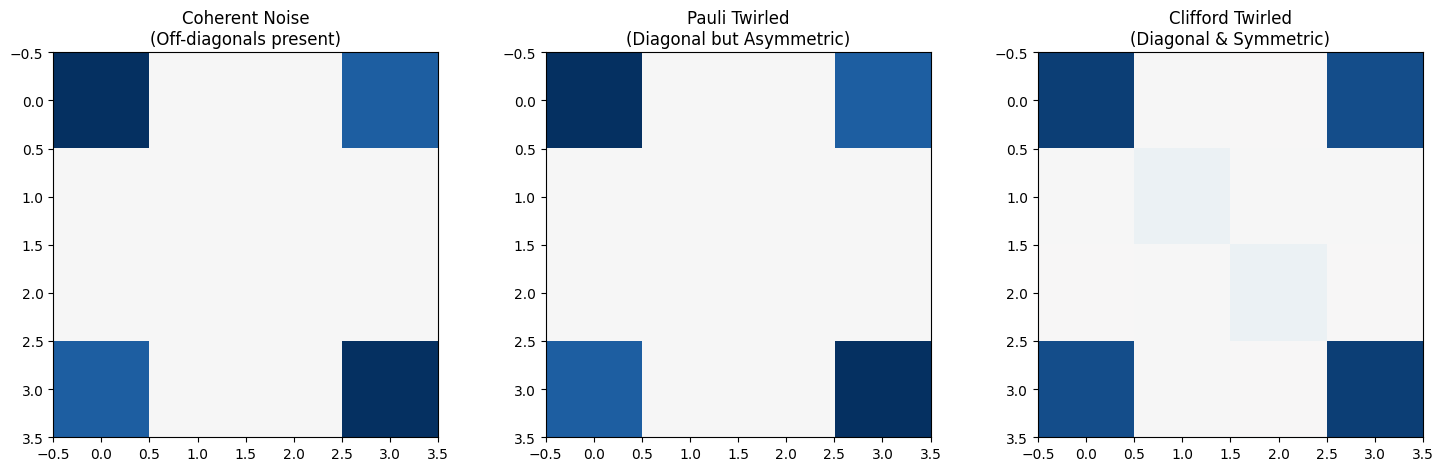

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Coherent Error (Real part)
# We look at the real part to see population shifts
axs[0].imshow(np.real(rho_coherent.data), cmap='RdBu', vmin=-0.5, vmax=0.5)
axs[0].set_title("Coherent Noise\n(Off-diagonals present)")

# 2. Pauli Twirled
axs[1].imshow(np.real(rho_pauli_twirled.data), cmap='RdBu', vmin=-0.5, vmax=0.5)
axs[1].set_title("Pauli Twirled\n(Diagonal but Asymmetric)")

# 3. Clifford Twirled
axs[2].imshow(np.real(rho_cliff_twirled.data), cmap='RdBu', vmin=-0.5, vmax=0.5)
axs[2].set_title("Clifford Twirled\n(Diagonal & Symmetric)")

plt.show()

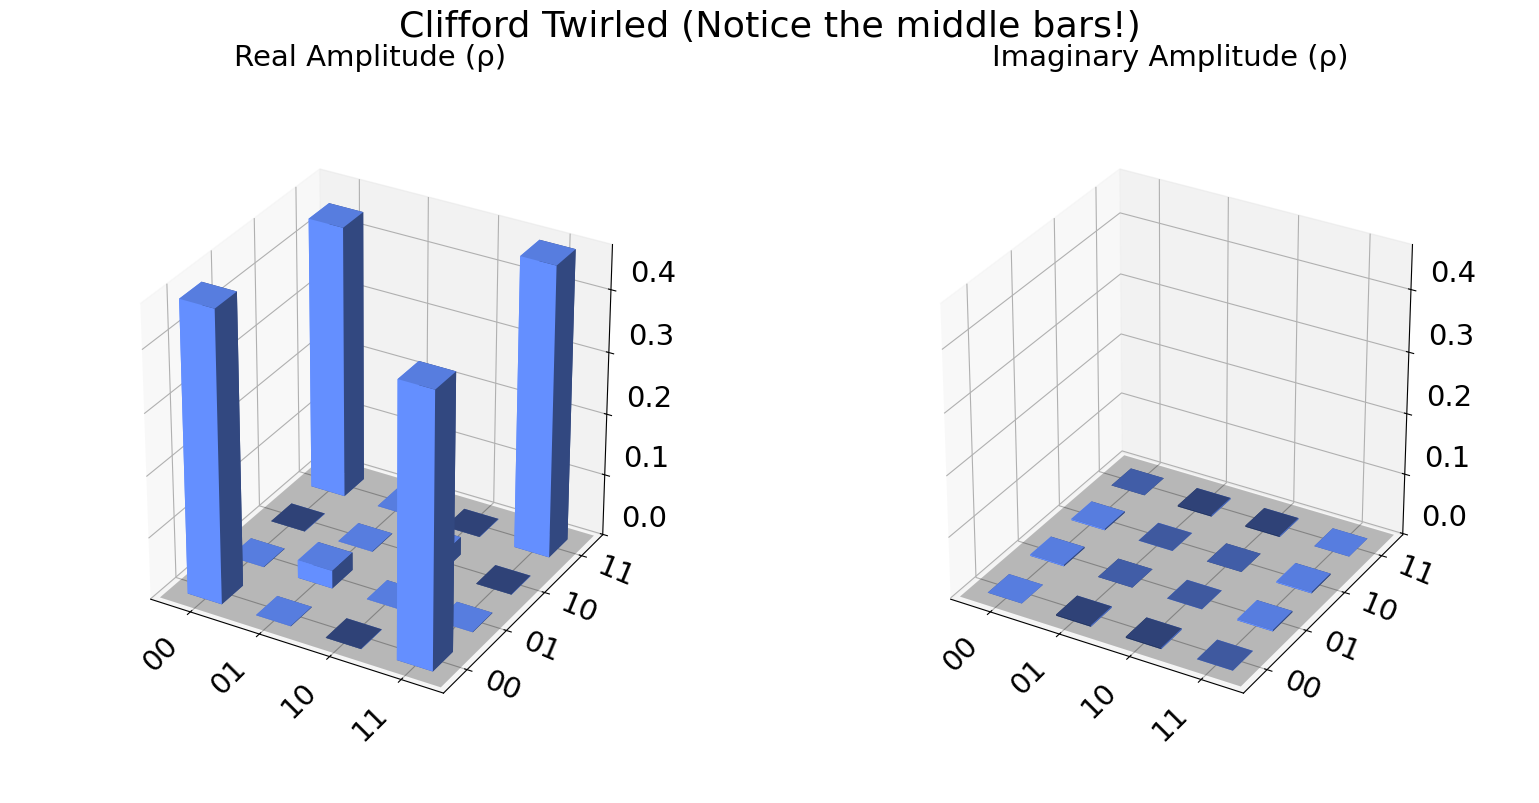

In [25]:
from qiskit.visualization import plot_state_city

# Visualize the Clifford Twirled state
# You will clearly see small bars appear at indices 1 and 2 (01 and 10)
# which proves the noise was symmetrized!
plot_state_city(rho_cliff_twirled, title="Clifford Twirled (Notice the middle bars!)")

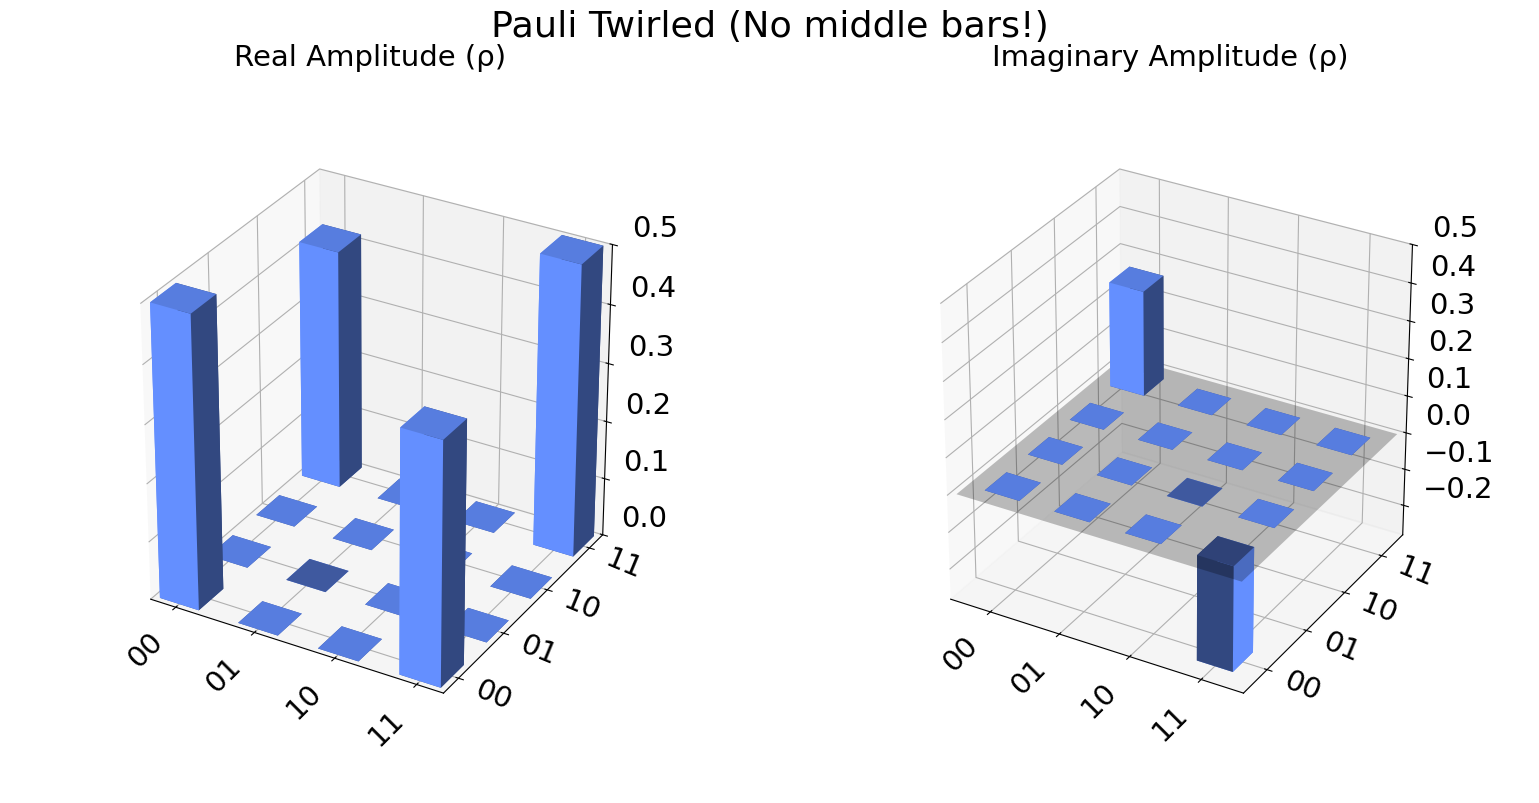

In [27]:
plot_state_city(rho_pauli_twirled, title="Pauli Twirled (No middle bars!)")

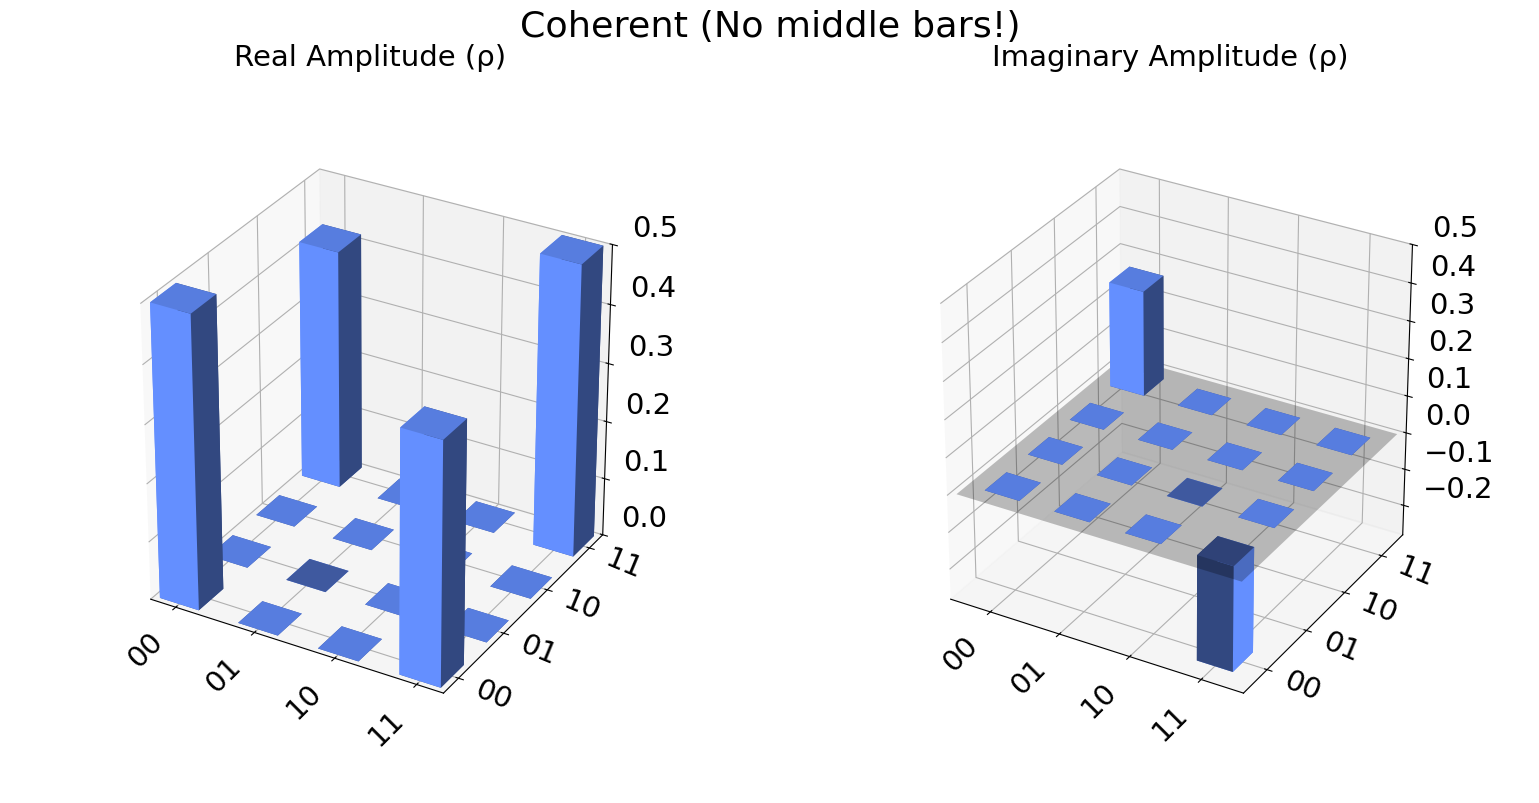

In [26]:
plot_state_city(rho_coherent, title="Coherent (No middle bars!)")

### Analysis of Results
If you check the matrices mathematically:
1. **Pauli Twirled:** The $Z$-rotation noise specifically damages terms like $\ket{0+}\bra{0+}$. Because we only used Pauli gates, the $Z$ error was preserved as a $Z$ error. It didn't turn into an $X$ error.
2. **Clifford Twirled:** The Clifford group includes the Hadamard gate ($H$). Since $H Z H = X$, randomly applying Cliffords converts some of our $Z$ errors into $X$ errors (and $Y$ errors via $S$).

This **symmetrization** turns the specific $Z$-rotation into a generic Depolarizing channel.